In [9]:
from rpy2.robjects.packages import importr
from rpy2 import robjects
from rpy2.robjects import FloatVector, globalenv

TOSTER = importr("TOSTER")

PackageNotInstalledError: The R package "TOSTER" is not installed.

# JaCoCo Visualization

In [10]:
import os

import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

jacoco_path = '../../generated/code-analysis/jacoco.csv'

if not os.path.exists(jacoco_path):
    raise FileNotFoundError(f"Le fichier JaCoCo n'existe pas : {jacoco_path}. Exécutez le notebook 'notebooks/arrange data/JaCoCo.ipynb' pour le générer.")

out_jacoco_path = '../../generated/figures/jacoco'
if not os.path.exists(out_jacoco_path):
    os.makedirs(out_jacoco_path)

df_jacoco = pd.read_csv(jacoco_path)
cols = ['instruction', 'branch', 'line']
col_labels = ['instruction', 'branche', 'ligne']

# Effet d'ordre

In [ ]:
results = []

for metric in cols:
    pivot = df_jacoco.pivot(index='user', columns='game_mode', values=metric)
    pivot = pivot.dropna()

    groups = df_jacoco.drop_duplicates('user')[['user', 'group']]
    pivot = pivot.merge(groups.set_index('user'), left_index=True, right_index=True)

    pivot['diff'] = pivot.apply(
        lambda row: row['leaderboard'] - row['achievements'] if row['group'] == 'A'
                    else row['achievements'] - row['leaderboard'],
        axis=1
    )

    group_a = pivot[pivot['group'] == 'A']['diff'].values.flatten()
    group_b = pivot[pivot['group'] == 'B']['diff'].values.flatten()

    assert len(group_a) == len(group_b), f"Mismatch in sample size for {metric}"

    _, p_normal_diff_a = stats.shapiro(group_a)
    _, p_normal_diff_b = stats.shapiro(group_b)

    group_a_r = FloatVector(group_a)
    group_b_r = FloatVector(group_b)

    robjects.globalenv["x"] = group_a_r
    robjects.globalenv["y"] = group_b_r

    test = robjects.r('''
        result <- wilcox_TOST(
            x = x, y = y,
            paired = FALSE,
            eqb = 0.1
        )
        result
    ''')

    tost = test.rx2("TOST")
    p_value = tost.rx2("p.value")[0]
    p_lower = tost.rx2("p.value")[1]
    p_upper = tost.rx2("p.value")[2]

    # Accès à la taille d'effet (rank biserial)
    effect_size = test.rx2("effsize")
    rbc = effect_size.rx2("estimate")[0]

    results.append([
        metric.capitalize(),
        p_normal_diff_a,
        p_normal_diff_b,
        p_value,
        p_lower,
        p_upper
    ])

order_effect_df = pd.DataFrame(results, columns=[
    'metric',
    'a_shapiro',
    'b_shapiro',
    'p_value',
    'p_lower',
    'p_upper'
])

# order_effect_df = order_effect_df.replace(True, 'Oui')
# order_effect_df = order_effect_df.replace(False, 'Non')
# order_effect_df = order_effect_df.round(5)
order_effect_df

C:\Users\fullb\AppData\Local\Temp\ipykernel_11764\1003327251.py:15: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p_normal_diff_a = stats.shapiro(group_a)


AttributeError: 'float' object has no attribute 'dtype'

In [4]:
order_effect_df_count = len(order_effect_df[(order_effect_df['p_lower'] > 0.05) & (order_effect_df['p_upper'] > 0.05)])
if order_effect_df_count > 0:
    print(f"Il y a un effet d'ordre")
else:
    print("Aucun effet d'ordre")

Aucun effet d'ordre


## Boxplot

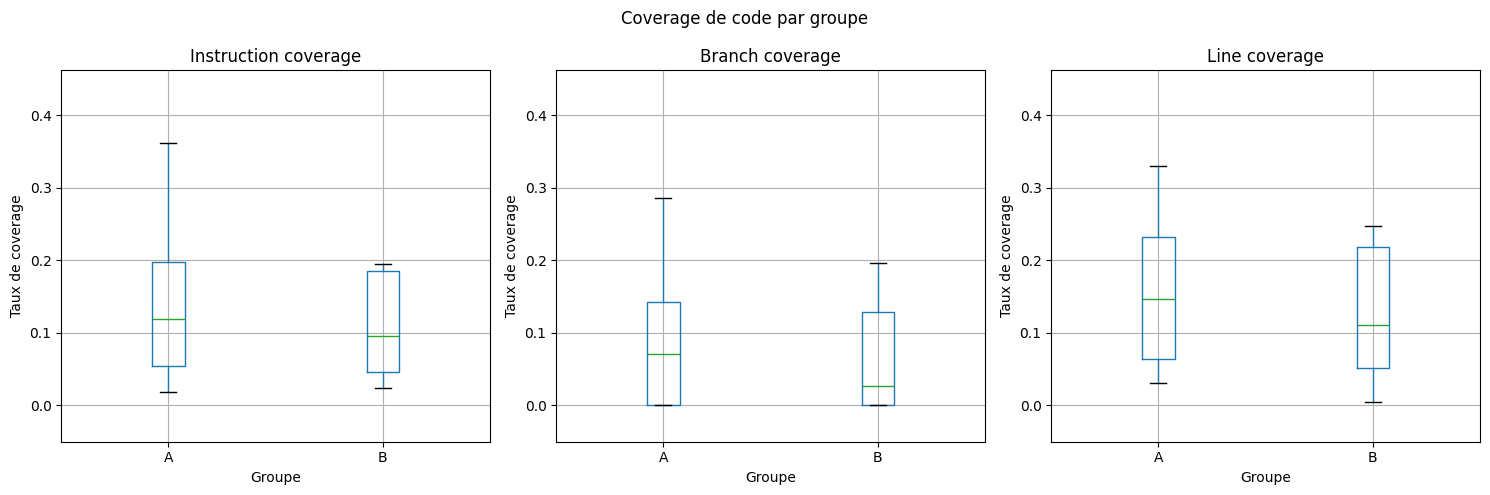

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.ravel()

y_max = df_jacoco[cols].max().max() + 0.1

for i, metric in enumerate(cols):
    ax = axs[i]
    bp = df_jacoco.boxplot(column=metric, by='group', ax=ax)
    ax.set_title(f'{metric.capitalize()} coverage')
    ax.set_ylabel('Taux de coverage')
    ax.set_xlabel('Groupe')
    ax.grid(True)
    ax.set_ylim(-0.05, y_max)

plt.suptitle('Coverage de code par groupe')
plt.tight_layout()
plt.savefig(f"{out_jacoco_path}/coverage_by_group.pdf")
plt.show()


# Effet de session

In [6]:
import numpy as np

results = []
alpha = 0.05

def diff_mean(data1, data2):
    return np.mean(data1) - np.mean(data2)

for metric in cols:
    df_rounds = df_jacoco.copy()

    session1 = df_rounds[df_rounds['session'] == 1][metric].values.flatten()
    session2 = df_rounds[df_rounds['session'] == 2][metric].values.flatten()

    assert len(session1) == len(session2), f"Mismatch in sample size for {metric}"

    # Normalité ?
    _, p_shapiro_1 = stats.shapiro(session1)
    _, p_shapiro_2 = stats.shapiro(session2)

    # Test variance
    stat, variance_p_value = stats.levene(session1, session2)

    test = robjects.r('''
        result <- wilcox_TOST(
            x = x, y = y,
            paired = TRUE,
            eqb = 0.1
        )
        result
    ''')

    tost = test.rx2("TOST")
    p_value = tost.rx2("p.value")[0]
    p_lower = tost.rx2("p.value")[1]
    p_upper = tost.rx2("p.value")[2]

    effect_size = test.rx2("effsize")
    rbc = effect_size.rx2("estimate")[0]

    session1_r = FloatVector(session1)
    session2_r = FloatVector(session2)

    robjects.globalenv["x"] = session1_r
    robjects.globalenv["y"] = session2_r


    results.append([
        metric.capitalize(),
        p_shapiro_1,
        p_shapiro_2,
        p_value,
        p_lower,
        p_upper
    ])

session_effect_df = pd.DataFrame(results, columns=[
    'metric',
    'session_1_normal',
    'session_2_normal',
    'p_value',
    'p_lower',
    'p_upper',
])

# session_effect_df = session_effect_df.replace(True, 'Oui')
# session_effect_df = session_effect_df.replace(False, 'Non')
# session_effect_df = session_effect_df.round(5)
session_effect_df

,metric,session_1_normal,session_2_normal,p_value,p_lower,p_upper
0,Instruction,0.012566,0.128463,0.624065,0.014987,0.040029
1,Branch,0.000710,0.067707,0.587170,0.004510,0.000292
2,Line,0.003756,0.395780,0.092389,0.010306,0.000271


In [7]:
session_effect_df_count = len(session_effect_df[session_effect_df['p_lower'] > 0.05] & session_effect_df['p_upper'] > 0.05)
if session_effect_df_count > 0:
    print(f"Il y a un effet de session")
else:
    print("Aucun effet de session")

Aucun effet de session


## Boxplot

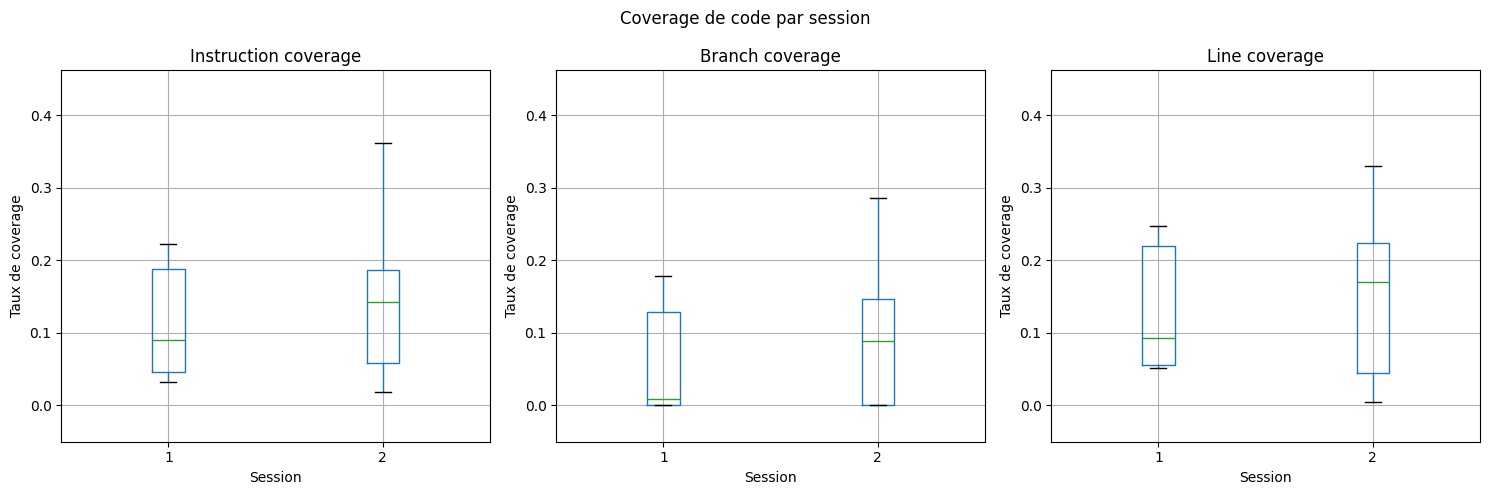

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.ravel()

y_max = df_jacoco[cols].max().max() + 0.1

for i, metric in enumerate(cols):
    ax = axs[i]
    bp = df_jacoco.boxplot(column=metric, by='session', ax=ax)
    ax.set_title(f'{metric.capitalize()} coverage')
    ax.set_ylabel('Taux de coverage')
    ax.set_xlabel('Session')
    ax.grid(True)
    ax.set_ylim(-0.05, y_max)

plt.suptitle('Coverage de code par session')
plt.tight_layout()
plt.savefig(f"{out_jacoco_path}/coverage_by_session.pdf")
plt.show()


# Meilleur mode

In [13]:
from notebooks.analysis import tests

best_mode_results = []
alpha = 0.05

for metric in cols:
    leaderboard = df_jacoco[(df_jacoco['game_mode'] == 'leaderboard')][metric].values.flatten()
    achievements = df_jacoco[(df_jacoco['game_mode'] == 'achievements')][metric].values.flatten()

    assert len(leaderboard) == len(achievements), f"Mismatch in sample size for {metric}"

    # Test de normalité
    _, p_normal_diff_leaderboard = stats.shapiro(leaderboard)
    _, p_normal_diff_achievements = stats.shapiro(achievements)

    t_stat, p_value = stats.wilcoxon(leaderboard, achievements)

    a12 = tests.vargha_delaney_a12(leaderboard, achievements)
    a12_label = tests.a12_label(a12)
    better_mode = "equals" if a12 == 0.5 else "achievements" if a12 > 0.5 else "leaderboard"

    best_mode_results.append([
        metric.capitalize(),
        p_normal_diff_leaderboard,
        p_normal_diff_achievements,
        p_value,
        a12,
        a12_label,
        better_mode
    ])


best_mode_df = pd.DataFrame(best_mode_results, columns=[
    'metric',
    'leaderboard_shapiro',
    'achievements_shapiro',
    'p_value',
    'vargha_delaney_a12',
    'vargha_delaney',
    'better_mode',
])

# best_mode_df = best_mode_df.replace(True, 'Oui')
# best_mode_df = best_mode_df.replace(False, 'Non')
# best_mode_df = best_mode_df.round(5)
best_mode_df

,metric,leaderboard_shapiro,achievements_shapiro,p_value,vargha_delaney_a12,vargha_delaney,better_mode
0,Instruction,0.036822,0.034328,0.495422,0.6250,Effet moyen,achievements
1,Branch,0.005093,0.004647,0.918760,0.5000,Aucun effet,equals
2,Line,0.172910,0.017420,0.836112,0.4375,Effet faible,leaderboard


# Graphiques

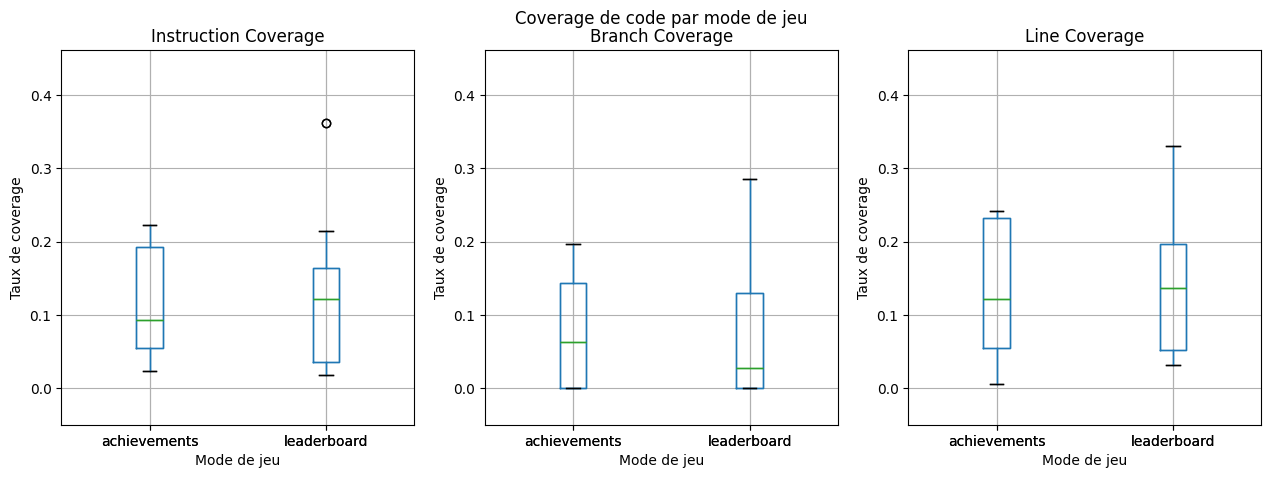

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.ravel()

y_max = df_jacoco[cols].max().max() + 0.1

for group in ['A', 'B']:
    for i, metric in enumerate(cols):
        ax = axs[i]
        bp = df_jacoco.boxplot(column=metric, by='game_mode', ax=ax)
        ax.set_title(f'{metric.capitalize()} Coverage')
        ax.set_ylabel('Taux de coverage')
        ax.set_xlabel('Mode de jeu')
        ax.grid(True)
        ax.set_ylim(-0.05, y_max)

plt.suptitle('Coverage de code par mode de jeu')
plt.savefig(f"{out_jacoco_path}/coverage_by_game_mode.pdf")
plt.show()